# Test Notebook: Importing OpenFOAM Case - Single Region
This notebook checks the functionalities of the pyforce package to handle OpenFOAM cases with a single region. It verifies that the package can correctly read and process the case files, adopting either *pyvista* or *fluidfoam* or *foamlib* as the backend.

In [1]:
from pyforce.tools.write_read import ReadFromOF
import time

path_case = 'TestDatasets/vortexShed/'

of_reconstructed = ReadFromOF(path_case, skip_zero_time=True, decomposed_case=False)
of_decomposed    = ReadFromOF(path_case, skip_zero_time=True, decomposed_case=True)

Case Type decomposed


Let us plot the mesh

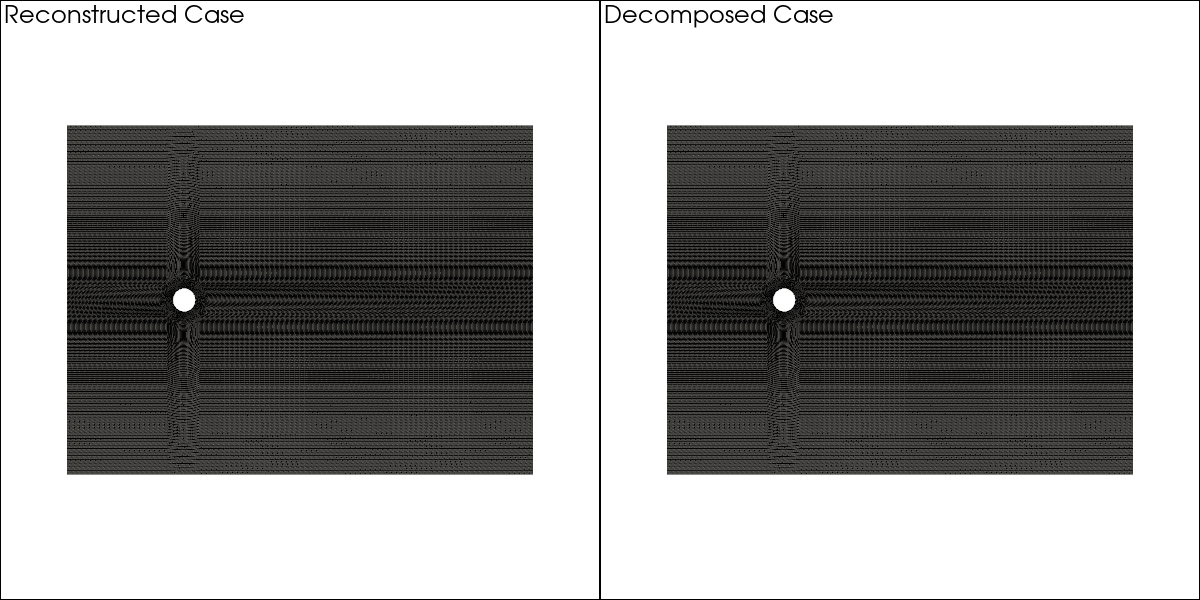

In [2]:
grids = {
    'reconstructed': of_reconstructed.mesh(),
    'decomposed': of_decomposed.mesh()
}

import pyvista as pv
pl = pv.Plotter(shape=(1, 2), window_size=(1200, 600))

pl.subplot(0, 0)
pl.add_text('Reconstructed Case', font_size=12)
pl.add_mesh(grids['reconstructed'], show_edges=True, color='white')
pl.view_xy()

pl.subplot(0, 1)
pl.add_text('Decomposed Case', font_size=12)
pl.add_mesh(grids['decomposed'], show_edges=True, color='white')
pl.view_xy()

pl.show(jupyter_backend='static')

## Reconstructed Case
The first check is on reconstructed data (either with \texttt{reconstructPar} or solved with single processor). Let us import the snapshots for the velocity and turbulent viscosity fields.

In [3]:
fields = ['p', 'nut', 'U']

comput_times_reconstructed  = {
    'Pyvista': {},
    'FluidFoam': {},
    'FoamLib': {}
}

snapshots_reconstructed = {
    'Pyvista': {},
    'FluidFoam': {},
    'FoamLib': {}
}


for field in fields:

    # Pyvista backend
    start_process_time = time.process_time()
    snapshots_reconstructed['Pyvista'][field] = of_reconstructed.import_field(field, import_mode='pyvista')
    comput_times_reconstructed['Pyvista'][field] = time.process_time() - start_process_time

    # FluidFoam backend
    start_process_time = time.process_time()
    snapshots_reconstructed['FluidFoam'][field] = of_reconstructed.import_field(field, import_mode='fluidfoam')
    comput_times_reconstructed['FluidFoam'][field] = time.process_time() - start_process_time

    # FoamLib backend
    start_process_time = time.process_time()
    snapshots_reconstructed['FoamLib'][field] = of_reconstructed.import_field(field, import_mode='foamlib')
    comput_times_reconstructed['FoamLib'][field] = time.process_time() - start_process_time

Ns = len(snapshots_reconstructed['Pyvista'][fields[0]])

Importing p using pyvista: 19.000 / 19.00 - 0.025000 s/it
Importing p using fluidfoam: 19.000 / 19.00 - 0.008782 s/it
Importing p using foamlib: 19.000 / 19.00 - 0.001125 s/it
Importing nut using pyvista: 19.000 / 19.00 - 0.022451 s/it
Importing nut using fluidfoam: 19.000 / 19.00 - 0.008595 s/it
Importing nut using foamlib: 19.000 / 19.00 - 0.001237 s/it
Importing U using pyvista: 19.000 / 19.00 - 0.022261 s/it
Importing U using fluidfoam: 19.000 / 19.00 - 0.026662 s/it
Importing U using foamlib: 19.000 / 19.00 - 0.001464 s/it


Plot a comparison of the computational times for both backends. 

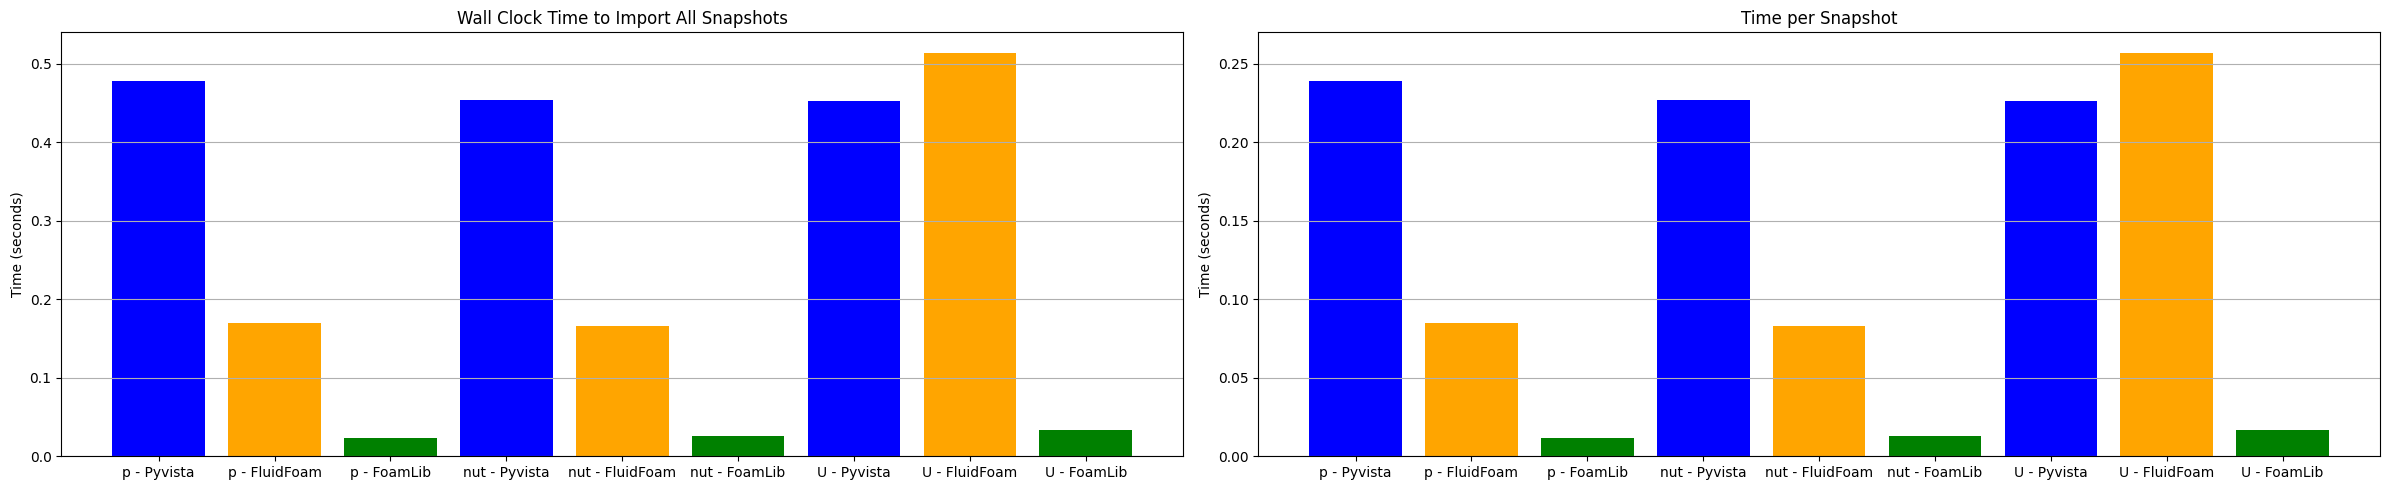

In [4]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(8 * len(fields), 5))
axs = axs.flatten()

for field in fields:
    axs[0].bar([f'{field} - Pyvista', f'{field} - FluidFoam', f'{field} - FoamLib'], [comput_times_reconstructed['Pyvista'][field], comput_times_reconstructed['FluidFoam'][field], comput_times_reconstructed['FoamLib'][field]], color=['blue', 'orange', 'green'])

    axs[1].bar([f'{field} - Pyvista', f'{field} - FluidFoam', f'{field} - FoamLib'], [comput_times_reconstructed['Pyvista'][field] / Ns, comput_times_reconstructed['FluidFoam'][field] / Ns, comput_times_reconstructed['FoamLib'][field] / Ns], color=['blue', 'orange', 'green'])

axs[0].set_title('Wall Clock Time to Import All Snapshots')
axs[1].set_title('Time per Snapshot')

for ax in axs:
    ax.set_ylabel('Time (seconds)')
    ax.grid(True, axis='y')

plt.tight_layout()

Plot for checking the fields

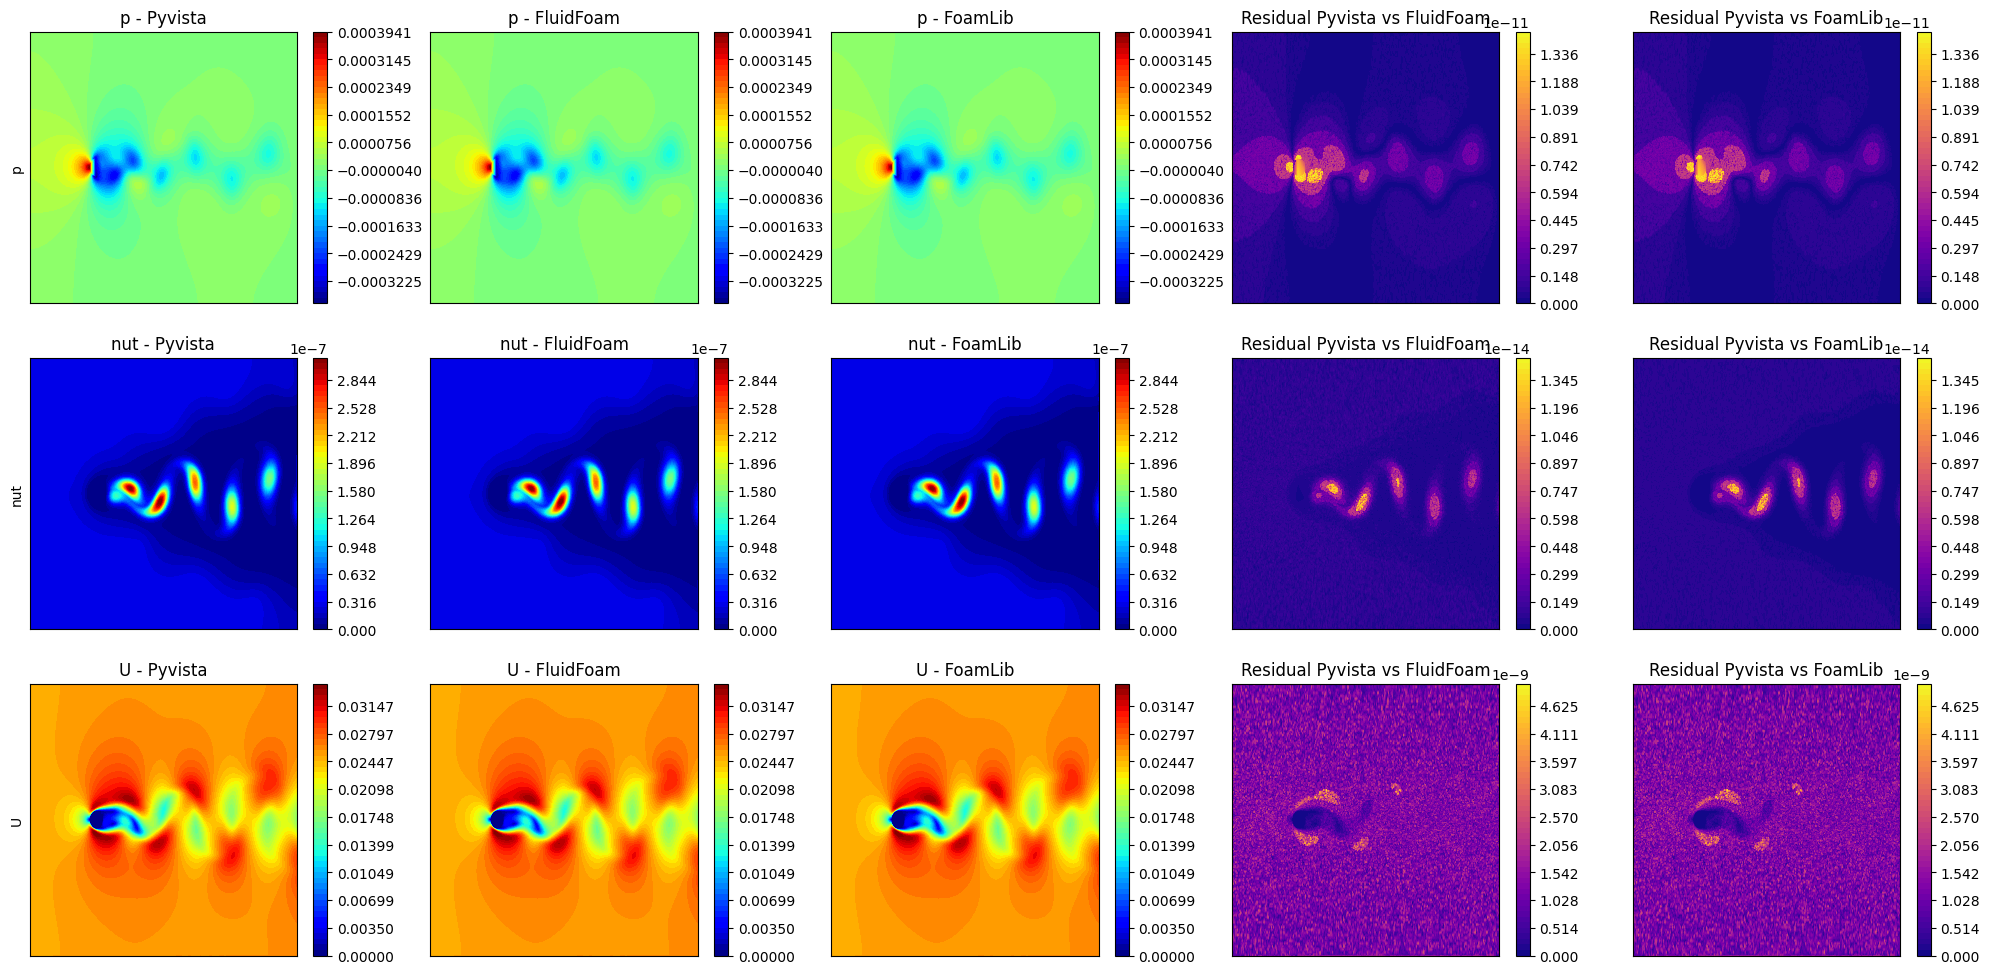

In [5]:
import numpy as np
nodes = of_reconstructed.mesh().cell_centers().points

fig, axs = plt.subplots(len(fields), (len(snapshots_reconstructed.keys())+2), figsize=(5 * (len(snapshots_reconstructed.keys())+2), 4 * len(fields)))

for i, field in enumerate(fields):
    pv_res_reconstructed = snapshots_reconstructed['Pyvista'][field][0](-1)
    ff_res_reconstructed = snapshots_reconstructed['FluidFoam'][field][0](-1)
    fl_res_reconstructed = snapshots_reconstructed['FoamLib'][field][0](-1)

    if field == 'U':
        _ff = np.linalg.norm(ff_res_reconstructed.reshape(-1, 3), axis=1)
        _pv = np.linalg.norm(pv_res_reconstructed.reshape(-1, 3), axis=1)
        _fl = np.linalg.norm(fl_res_reconstructed.reshape(-1, 3), axis=1)
    else:
        _ff = ff_res_reconstructed
        _pv = pv_res_reconstructed
        _fl = fl_res_reconstructed

    levels = np.linspace(min(_ff.min(), _pv.min()), max(_ff.max(), _pv.max()), 50)

    c = axs[i, 0].tricontourf(nodes[:, 0], nodes[:, 1], _pv, levels=levels, cmap='jet')
    axs[i, 1].tricontourf(nodes[:, 0], nodes[:, 1], _ff, levels=levels, cmap='jet')
    axs[i, 2].tricontourf(nodes[:, 0], nodes[:, 1], _fl, levels=levels, cmap='jet')

    _res_ff = np.abs(_ff - _pv)
    _res_fl = np.abs(_fl - _pv)
    res_levels = np.linspace(0, max(_res_ff.max(), _res_fl.max()), 50)
    c_res = axs[i, 3].tricontourf(nodes[:, 0], nodes[:, 1], _res_ff, levels=res_levels, cmap='plasma')
    axs[i, 4].tricontourf(nodes[:, 0], nodes[:, 1], _res_fl, levels=res_levels, cmap='plasma')

    fig.colorbar(c, ax=axs[i, 0])
    fig.colorbar(c, ax=axs[i, 1])
    fig.colorbar(c, ax=axs[i, 2])

    fig.colorbar(c_res, ax=axs[i, 3])
    fig.colorbar(c_res, ax=axs[i, 4])

    axs[i, 0].set_title(f'{field} - Pyvista')
    axs[i, 1].set_title(f'{field} - FluidFoam')
    axs[i, 2].set_title(f'{field} - FoamLib')

    axs[i, 3].set_title(f'Residual Pyvista vs FluidFoam')
    axs[i, 4].set_title(f'Residual Pyvista vs FoamLib')

    axs[i, 0].set_ylabel(f'{field}')

for ax in axs.flatten():
    ax.set_xticks([])
    ax.set_yticks([])

## Decomposed Case
Let us now check the decomposed case.

In [6]:
comput_times_decomposed  = {
    'Pyvista': {},
    'FluidFoam': {},
    'FoamLib': {}
}

snapshots_decomposed = {
    'Pyvista': {},
    'FluidFoam': {},
    'FoamLib': {}
}

for field in fields:

    # Pyvista backend
    start_process_time = time.process_time()
    snapshots_decomposed['Pyvista'][field] = of_decomposed.import_field(field, import_mode='pyvista')
    comput_times_decomposed['Pyvista'][field] = time.process_time() - start_process_time

    # FluidFoam backend
    start_process_time = time.process_time()
    snapshots_decomposed['FluidFoam'][field] = of_decomposed.import_field(field, import_mode='fluidfoam')
    comput_times_decomposed['FluidFoam'][field] = time.process_time() - start_process_time

    # FoamLib backend
    start_process_time = time.process_time()
    snapshots_decomposed['FoamLib'][field] = of_decomposed.import_field(field, import_mode='foamlib')
    comput_times_decomposed['FoamLib'][field] = time.process_time() - start_process_time

Importing p using pyvista: 19.000 / 19.00 - 0.031267 s/it
Importing p using fluidfoam: 19.000 / 19.00 - 0.009116 s/it
Importing p using foamlib: 19.000 / 19.00 - 0.004814 s/it
Importing nut using pyvista: 19.000 / 19.00 - 0.024906 s/it
Importing nut using fluidfoam: 19.000 / 19.00 - 0.008898 s/it
Importing nut using foamlib: 19.000 / 19.00 - 0.005482 s/it
Importing U using pyvista: 19.000 / 19.00 - 0.026548 s/it
Importing U using fluidfoam: 19.000 / 19.00 - 0.026231 s/it
Importing U using foamlib: 19.000 / 19.00 - 0.005666 s/it


Plot a comparison of the computational times for both backends. 

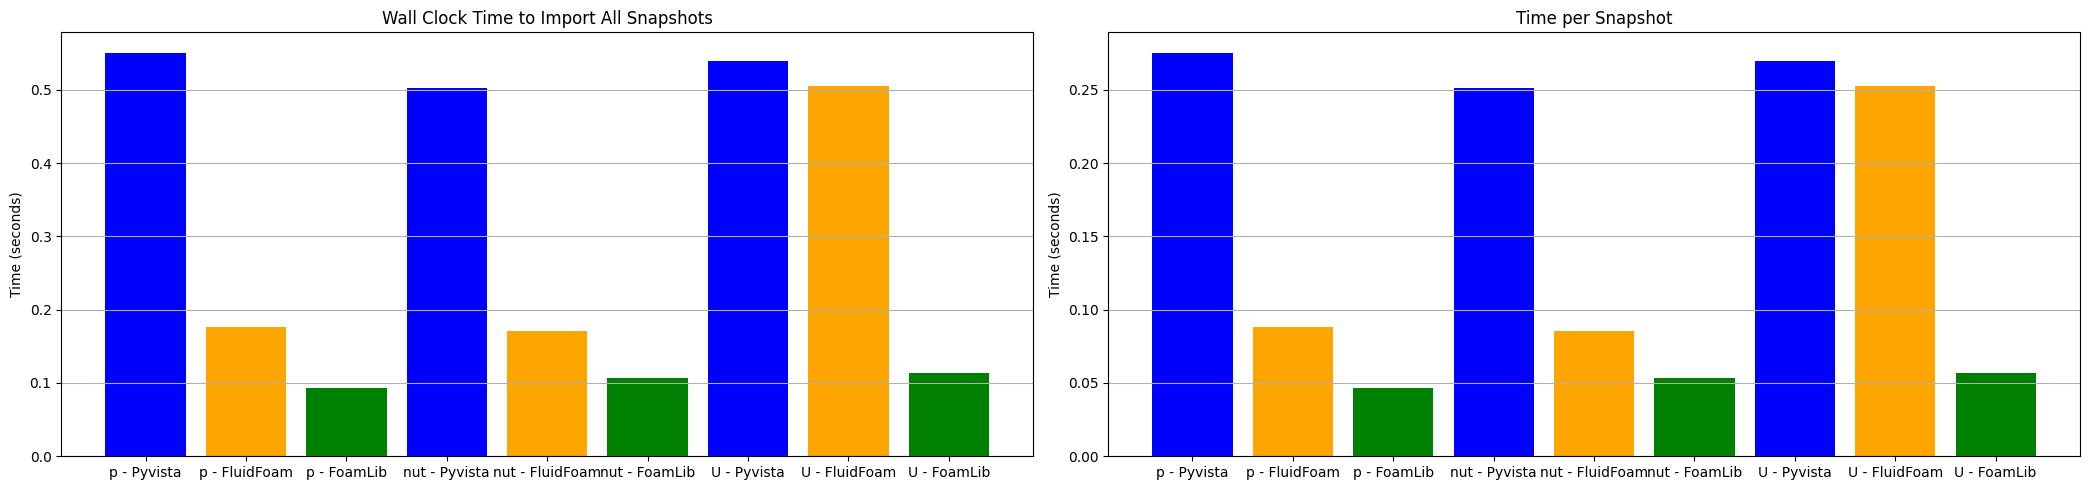

In [7]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(7 * len(fields), 5))
axs = axs.flatten()

for field in fields:
    axs[0].bar([f'{field} - Pyvista', f'{field} - FluidFoam', f'{field} - FoamLib'], [comput_times_decomposed['Pyvista'][field], comput_times_decomposed['FluidFoam'][field], comput_times_decomposed['FoamLib'][field]], color=['blue', 'orange', 'green'])

    axs[1].bar([f'{field} - Pyvista', f'{field} - FluidFoam', f'{field} - FoamLib'], [comput_times_decomposed['Pyvista'][field] / Ns, comput_times_decomposed['FluidFoam'][field] / Ns, comput_times_decomposed['FoamLib'][field] / Ns], color=['blue', 'orange', 'green'])    

axs[0].set_title('Wall Clock Time to Import All Snapshots')
axs[1].set_title('Time per Snapshot')

for ax in axs:
    ax.set_ylabel('Time (seconds)')
    ax.grid(True, axis='y')

plt.tight_layout()

Plot for checking the fields

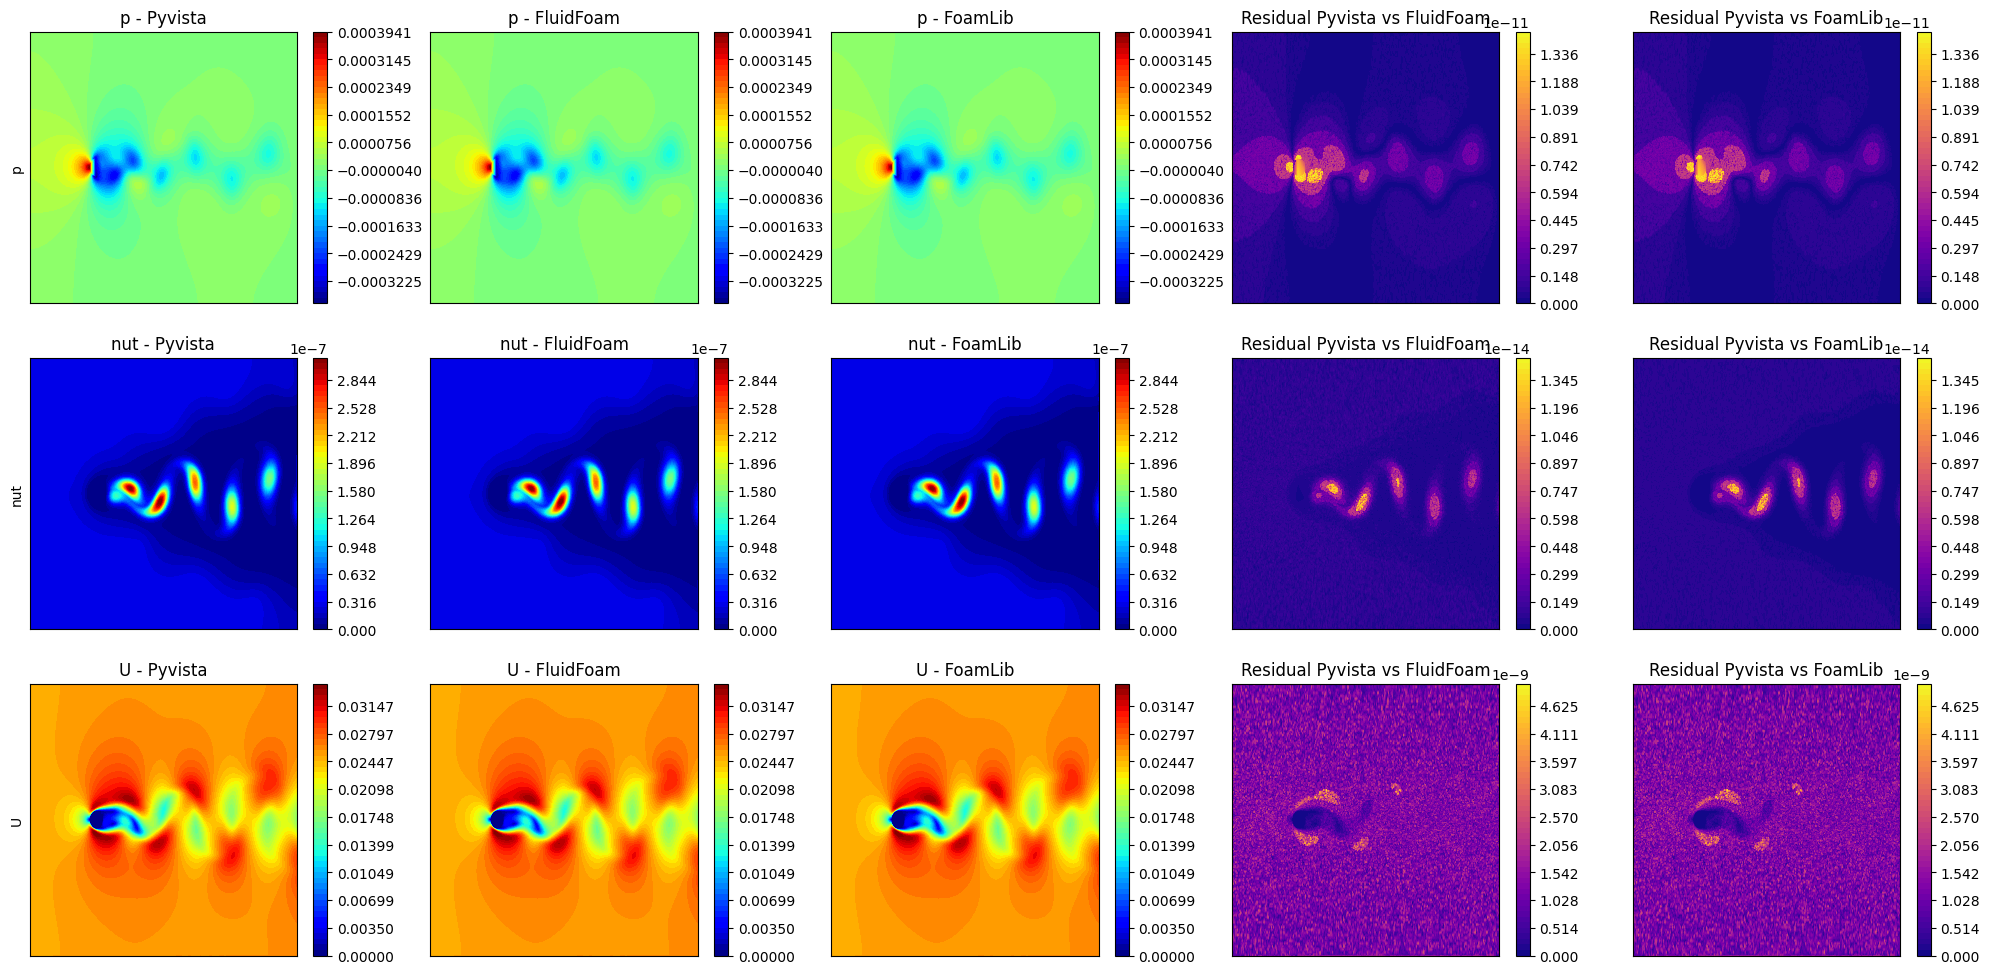

In [8]:
import numpy as np
nodes = of_decomposed.mesh().cell_centers().points

fig, axs = plt.subplots(len(fields), len(snapshots_decomposed.keys())+2, figsize=(5 * (len(snapshots_decomposed.keys())+2), 4 * len(fields)))

for i, field in enumerate(fields):

    ff_res_decomposed = snapshots_decomposed['FluidFoam'][field][0](-1)
    pv_res_decomposed = snapshots_decomposed['Pyvista'][field][0](-1)
    fl_res_decomposed = snapshots_decomposed['FoamLib'][field][0](-1)

    if field == 'U':
        _ff = np.linalg.norm(ff_res_decomposed.reshape(-1, 3), axis=1)
        _pv = np.linalg.norm(pv_res_decomposed.reshape(-1, 3), axis=1)
        _fl = np.linalg.norm(fl_res_decomposed.reshape(-1, 3), axis=1)
    else:
        _ff = ff_res_decomposed
        _pv = pv_res_decomposed
        _fl = fl_res_decomposed

    levels = np.linspace(min(_ff.min(), _pv.min(), _fl.min()), max(_ff.max(), _pv.max(), _fl.max()), 50)

    c = axs[i, 0].tricontourf(nodes[:, 0], nodes[:, 1], _pv, levels=levels, cmap='jet')
    axs[i, 1].tricontourf(nodes[:, 0], nodes[:, 1], _ff, levels=levels, cmap='jet')
    axs[i, 2].tricontourf(nodes[:, 0], nodes[:, 1], _fl, levels=levels, cmap='jet')

    _res_ff = np.abs(_ff - _pv)
    _res_fl = np.abs(_fl - _pv)
    res_levels = np.linspace(0, max(_res_ff.max(), _res_fl.max()), 50)
    c_res = axs[i, 3].tricontourf(nodes[:, 0], nodes[:, 1], _res_ff, levels=res_levels, cmap='plasma')
    axs[i, 4].tricontourf(nodes[:, 0], nodes[:, 1], _res_fl, levels=res_levels, cmap='plasma')
    
    fig.colorbar(c, ax=axs[i, 0])
    fig.colorbar(c, ax=axs[i, 1])
    fig.colorbar(c, ax=axs[i, 2])

    fig.colorbar(c_res, ax=axs[i, 3])
    fig.colorbar(c_res, ax=axs[i, 4])

    axs[i, 0].set_title(f'{field} - Pyvista')
    axs[i, 1].set_title(f'{field} - FluidFoam')
    axs[i, 2].set_title(f'{field} - FoamLib')

    axs[i, 3].set_title(f'Residual Pyvista vs FluidFoam')
    axs[i, 4].set_title(f'Residual Pyvista vs FoamLib')

    axs[i, 0].set_ylabel(f'{field}')

for ax in axs.flatten():
    ax.set_xticks([])
    ax.set_yticks([])

Check mesh stacking

In [9]:
_nodes_stacked = of_decomposed._read_stacked_processor_mesh_fluidfoam()
np.abs(_nodes_stacked - nodes).max()

2.759417649933482e-08